# Informations extraction (url and label) for Thierry

Mots-clé: https://basex.inha.fr/ThierryNum/metadata

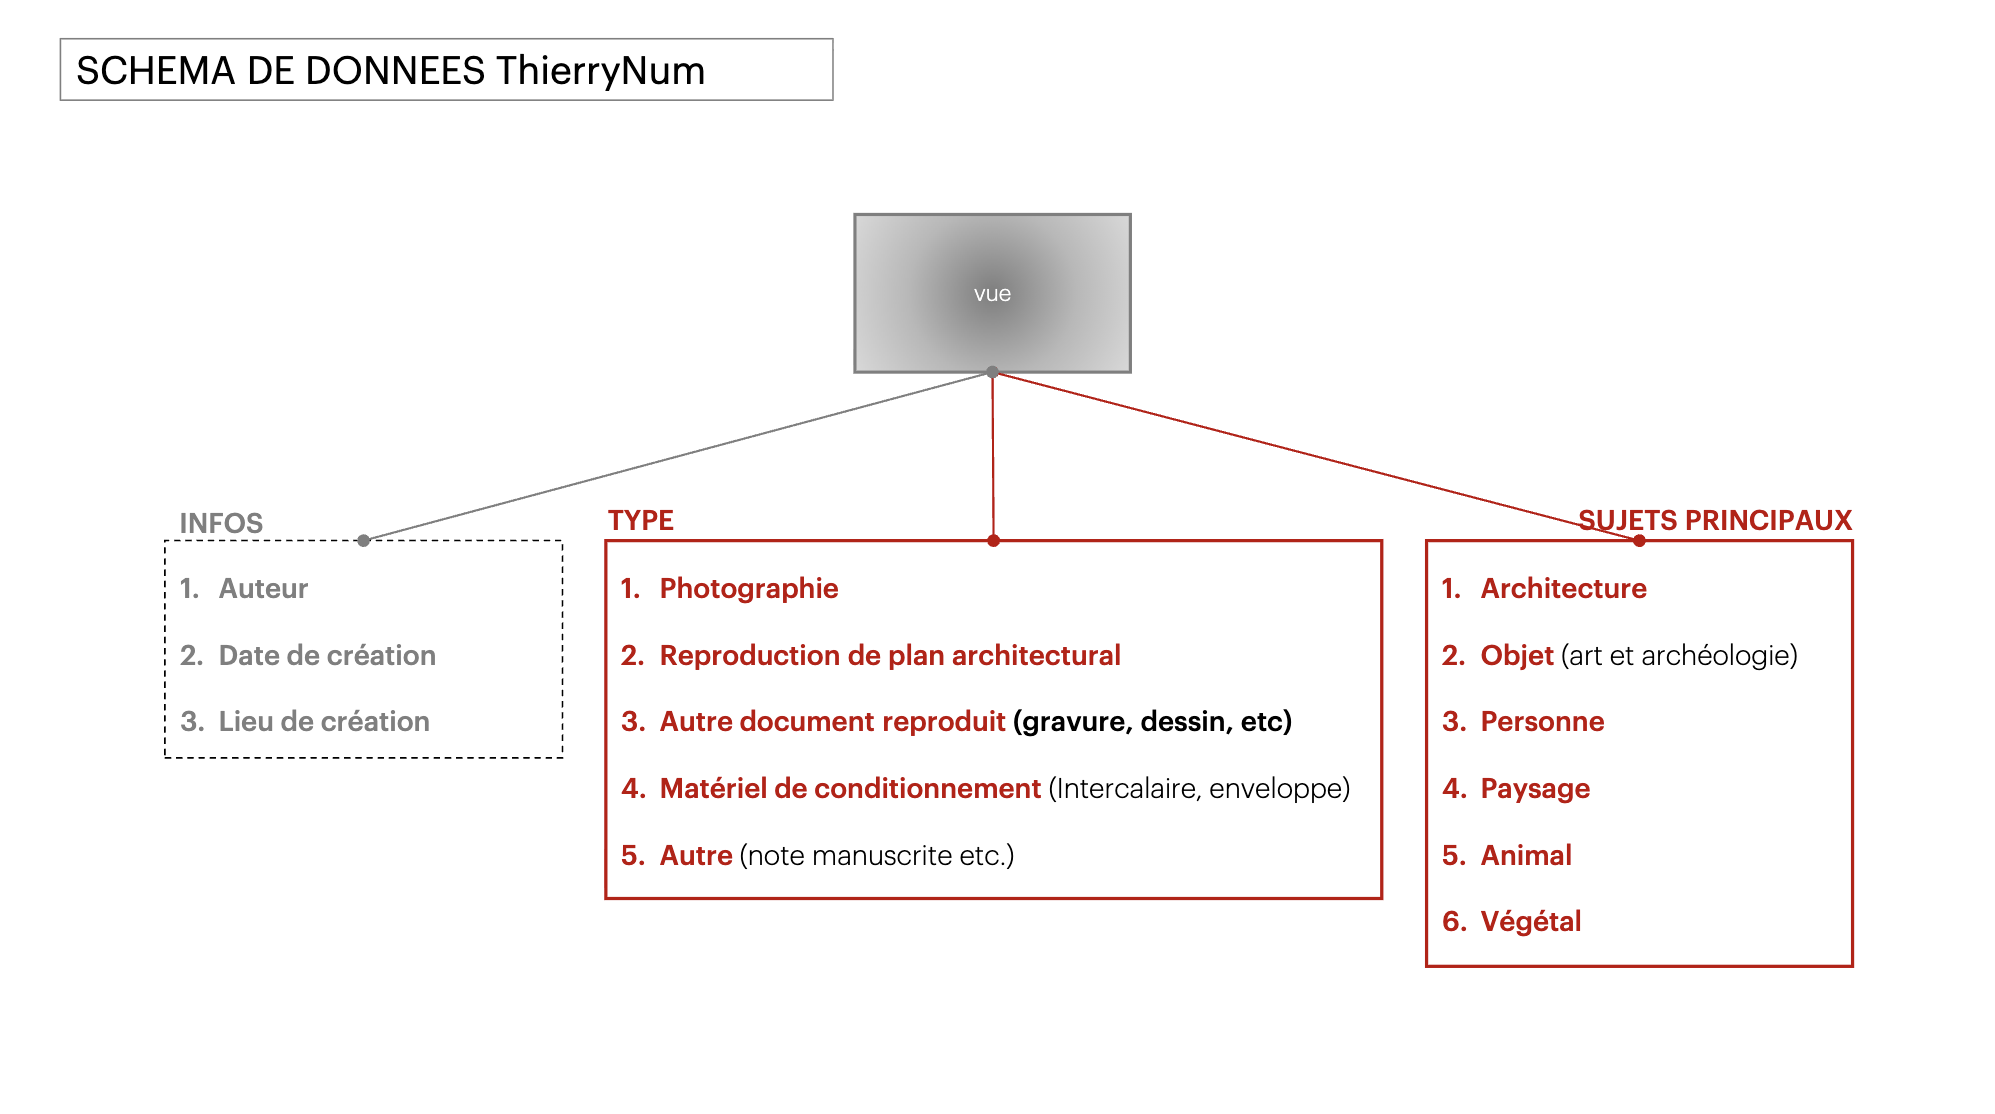

1) Utiliser json avec les annotation des images (annotation manuelle de l’équipe)
2) Extraction titres images et annotations associées
3) Creation dataframe (CSV)

### Passages extraction info du Json

> Elements d'interesse: ["@graph"]["titre"] = Titres de l'image; ["@graph"]["photo"]["tag"] = Annotations

> ["tag"] Liste avec arborescence --> extraîre le premier élément de la liste

> Charger le json comme dict, clé ["@graph"]["titre"] et ["@graph"]["photo"]["tag"], extraîre le premier élément de la liste tag.

> A partir du json créer un dataframe (csv) avec ["Titre image"] et une colonne pour chaque tag
> Une fois qu'on a le df on crée un dossier pour chaque ["tag"] avec l'image
> Pour extraîre plus facilement --> nom dossier = nom classe

# Extraction titres images et annotations associées

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json

In [ ]:
# Opening JSON file
with open('info_thierry.json') as json_file:
    data = json.load(json_file)

In [ ]:
# exploring the JSON structure
title = data["@graph"][0]["title"]
tag = data["@graph"][0]["tag"]

In [ ]:
title
tag

['1.4. Matériel de conditionnement']

In [ ]:
# Extracting all titles and tags
titles = []
tags = []

for item in data.get("@graph", []):
    if "title" in item:
        titles.append(item["title"])

    if "tag" in item:
        tags.extend(item["tag"])


In [ ]:
titles

In [ ]:
# Creating a list of dictionaries with titles and tags
rows = []

for item in data.get("@graph", []):
    title = item.get("title")
    tags = item.get("tag", [])
    tag_ord = sorted(tags)

    if title:
        rows.append({
            "title": title,
            "tags": tag_ord
        })


In [ ]:
# Finding the maximum number of tags in any row
max_tags = max(len(row["tags"]) for row in rows)


In [ ]:
# Creating CSV rows with dynamic tag columns
csv_rows = []

for row in rows:
    csv_row = {"title": row["title"]}

    for i in range(max_tags):
        csv_row[f"tag_{i+1}"] = row["tags"][i] if i < len(row["tags"]) else ""

    csv_rows.append(csv_row)


In [ ]:
# Writing to CSV file
import csv

fieldnames = ["title"] + [f"tag_{i+1}" for i in range(max_tags)]

with open("output.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(csv_rows)


In [ ]:
#%pip install pandas

## Extraction of url of images from the file and insert to the csv

In [ ]:
%pip install requests

In [ ]:
import pandas as pd
import re

# 1. Charger le CSV
df = pd.read_csv("output.csv")

# 2. Extraîre la clé du titre
df["key"] = df["title"].str.extract(
    r"([A-Za-z0-9]+(?:_\d+)+)"
)

# 3. Normalisation du numéro final du nom du fichier (001 -> 1)
df["key"] = df["key"].apply(
    lambda x: re.sub(
        r"_(\d+)$",
        lambda m: f"_{int(m.group(1))}",
        x
    ) if isinstance(x, str) else x
)

# 4. Lecture de l'URL
with open("images_url.txt", "r") as f:
    links = [line.strip() for line in f if line.strip()]

# 5. Costruire link_map[key] = link
link_map = {}

for link in links:
    match = re.search(
        r"([A-Za-z0-9]+(?:_\d+)+)\.tif",
        link
    )
    if match:
        key = match.group(1)
        key = re.sub(
            r"_(\d+)$",
            lambda m: f"_{int(m.group(1))}",
            key
        )
        link_map[key] = link

# 6. CréAtion de la colonne image_url
df["image_url"] = df["key"].map(link_map)

# 7. Insérer la colonne image_url comme deuxième colonne
cols = df.columns.tolist()
cols.insert(1, cols.pop(cols.index("image_url")))
df = df[cols]

# 8. Supprimer la colonne technique
df.drop(columns=["key"], inplace=True)

# 9. Sauvegarder le CSV final
df.to_csv("images_with_links.csv", index=False)


Attention: pour le passage suivant on utilise le fichier images_with_link_OK.csv créé à la main pou résoudre certain problème avec les tags (fichiers sans tag_1)

In [ ]:
import csv
import os
import time
import random
import requests
from urllib.parse import urlparse

# === CONFIGURATION ===
CSV_FILE = "images_with_links_OK.csv"
OUTPUT_DIR = "images"
MIN_DELAY = 0.5   # secondes
MAX_DELAY = 1.5   # secondes
TIMEOUT = 15      # requête timeout HTTP

# =====================

os.makedirs(OUTPUT_DIR, exist_ok=True)

def sanitize_filename(name):
    """Supprime les caractères non valides des noms des fichiers"""
    return "".join(c for c in name if c.isalnum() or c in (" ", "_", "-")).rstrip()

with open(CSV_FILE, newline="", encoding="utf-8") as csvfile:
    reader = csv.DictReader(csvfile)

    for row in reader:
        title = sanitize_filename(row["title"])
        image_url = row["image_url"]
        tag = sanitize_filename(row["tag_1"])

        # Dossier pour le tag
        tag_dir = os.path.join(OUTPUT_DIR, tag)
        os.makedirs(tag_dir, exist_ok=True)

        # Extension fichier à partir des URL
        parsed_url = urlparse(image_url)
        ext = os.path.splitext(parsed_url.path)[1] or ".jpg"

        file_path = os.path.join(tag_dir, f"{title}{ext}")

        try:
            print(f"En cours de téléchargement: {title}")
            response = requests.get(image_url, timeout=TIMEOUT)
            response.raise_for_status()

            with open(file_path, "wb") as f:
                f.write(response.content)

            print(f"Sauvegardé ici: {file_path}")

        except Exception as e:
            print(f"Erreur {image_url}: {e}")

        # Timeout
        delay = random.uniform(MIN_DELAY, MAX_DELAY)
        print(f"Attente {delay:.2f} secondes...\n")
        time.sleep(delay)

print("Téléchargement terminé")


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
✅ Salvata in: images/11 Photographie/B751025206PH04PHOT68_bureauJMT_01_8_1_086.jpg
⏳ Attendo 1.22 secondi...

⬇️  Scarico: B751025206PH04PHOT68_bureauJMT_01_8_1_087
✅ Salvata in: images/11 Photographie/B751025206PH04PHOT68_bureauJMT_01_8_1_087.jpg
⏳ Attendo 0.58 secondi...

⬇️  Scarico: B751025206PH04PHOT68_bureauJMT_01_8_1_088
✅ Salvata in: images/11 Photographie/B751025206PH04PHOT68_bureauJMT_01_8_1_088.jpg
⏳ Attendo 0.63 secondi...

⬇️  Scarico: B751025206PH04PHOT68_bureauJMT_01_8_1_089
✅ Salvata in: images/11 Photographie/B751025206PH04PHOT68_bureauJMT_01_8_1_089.jpg
⏳ Attendo 1.47 secondi...

⬇️  Scarico: B751025206PH04PHOT68_bureauJMT_01_8_1_090
✅ Salvata in: images/11 Photographie/B751025206PH04PHOT68_bureauJMT_01_8_1_090.jpg
⏳ Attendo 1.37 secondi...

⬇️  Scarico: B751025206PH04PHOT68_bureauJMT_01_8_2_001
✅ Salvata in: images/14 Matériel de conditionnement/B751025206PH04PHOT68_bureauJMT_01_8_2_001.jpg